#Notebook 2: MIMIC-III Demo Dataset
**Fuente:** https://physionet.org/content/mimiciii-demo/1.4/

MIMIC-III es una base de datos clínica de cuidados intensivos. La versión demo contiene datos anonimizados de ~100 pacientes. Este notebook se enfoca en la tabla principal de admisiones (`ADMISSIONS.csv`) para preparar un dataset de predicción de mortalidad hospitalaria.

## Introducción
MIMIC-III Demo contiene múltiples tablas CSV. Utilizaremos `ADMISSIONS.csv` y `PATIENTS.csv` como tablas principales para construir un dataset de clasificación binaria: **predicción de mortalidad hospitalaria** (HOSPITAL_EXPIRE_FLAG). Este es un problema de **clasificación binaria** (0 = vivo al alta, 1 = fallecido en hospital).

## Carga del Dataset
Descarga las tablas desde PhysioNet (requiere registro). Coloca los archivos en Google Drive o en el directorio local.

In [3]:
import os
import pandas as pd
import numpy as np

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Entorno local detectado.')

if IN_COLAB:
    BASE_PATH   = '/content/drive/MyDrive/datasets/mimic-iii-clinical-database-demo-1.4/mimic-iii-clinical-database-demo-1.4/'
    EXPORT_PATH = '/content/drive/MyDrive/datasets/mimic-iii-demo/output/'
else:
    BASE_PATH   = './mimic-iii-demo/'
    EXPORT_PATH = './mimic-iii-demo/output/'

os.makedirs(EXPORT_PATH, exist_ok=True)

admissions = pd.read_csv(os.path.join(BASE_PATH, 'ADMISSIONS.csv'))
patients   = pd.read_csv(os.path.join(BASE_PATH, 'PATIENTS.csv'))

print(f'ADMISSIONS: {admissions.shape}')
print(f'PATIENTS:   {patients.shape}')
admissions.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ADMISSIONS: (129, 19)
PATIENTS:   (100, 8)


,row_id,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,religion,marital_status,ethnicity,edregtime,edouttime,diagnosis,hospital_expire_flag,has_chartevents_data
0,12258,10006,142345,2164-10-23 21:09:00,2164-11-01 17:15:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,SEPARATED,BLACK/AFRICAN AMERICAN,2164-10-23 16:43:00,2164-10-23 23:00:00,SEPSIS,0,1
1,12263,10011,105331,2126-08-14 22:32:00,2126-08-28 18:59:00,2126-08-28 18:59:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Private,NaN,CATHOLIC,SINGLE,UNKNOWN/NOT SPECIFIED,NaN,NaN,HEPATITIS B,1,1
2,12265,10013,165520,2125-10-04 23:36:00,2125-10-07 15:13:00,2125-10-07 15:13:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,NaN,CATHOLIC,NaN,UNKNOWN/NOT SPECIFIED,NaN,NaN,SEPSIS,1,1
3,12269,10017,199207,2149-05-26 17:19:00,2149-06-03 18:42:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,NaN,CATHOLIC,DIVORCED,WHITE,2149-05-26 12:08:00,2149-05-26 19:45:00,HUMERAL FRACTURE,0,1
4,12270,10019,177759,2163-05-14 20:43:00,2163-05-15 12:00:00,2163-05-15 12:00:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,NaN,CATHOLIC,DIVORCED,WHITE,NaN,NaN,ALCOHOLIC HEPATITIS,1,1


 Identificación del Tipo de Problema

In [5]:
TARGET = 'hospital_expire_flag'
print(f'Variable objetivo: {TARGET}')
print(f'Distribución:\n{admissions[TARGET].value_counts()}')
print('\n→ Tipo de problema: CLASIFICACIÓN BINARIA')
print('   0 = Paciente dado de alta vivo')
print('   1 = Paciente fallecido en hospital')

Variable objetivo: hospital_expire_flag
Distribución:
hospital_expire_flag
0    89
1    40
Name: count, dtype: int64

→ Tipo de problema: CLASIFICACIÓN BINARIA
   0 = Paciente dado de alta vivo
   1 = Paciente fallecido en hospital


### Análisis Exploratorio (EDA)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print('=== ADMISSIONS - Info ===')
admissions.info()
print('\n=== Valores nulos ===')
print(admissions.isnull().sum())

=== ADMISSIONS - Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   row_id                129 non-null    int64 
 1   subject_id            129 non-null    int64 
 2   hadm_id               129 non-null    int64 
 3   admittime             129 non-null    object
 4   dischtime             129 non-null    object
 5   deathtime             40 non-null     object
 6   admission_type        129 non-null    object
 7   admission_location    129 non-null    object
 8   discharge_location    129 non-null    object
 9   insurance             129 non-null    object
 10  language              81 non-null     object
 11  religion              128 non-null    object
 12  marital_status        113 non-null    object
 13  ethnicity             129 non-null    object
 14  edregtime             92 non-null     object
 15  edouttime     

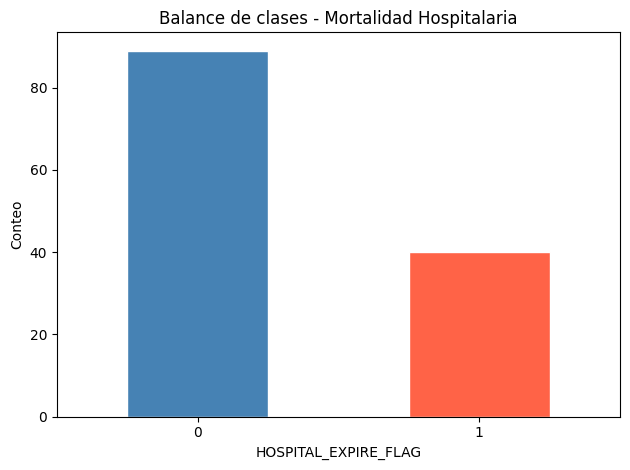

In [7]:
# Balance de clases
admissions[TARGET].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='white')
plt.title('Balance de clases - Mortalidad Hospitalaria')
plt.xlabel('HOSPITAL_EXPIRE_FLAG')
plt.ylabel('Conteo')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Tipos de admisión
print('Tipos de admisión:')
print(admissions['admission_type'].value_counts())
print('\nTipos de alta:')
print(admissions['discharge_location'].value_counts())

Tipos de admisión:
admission_type
EMERGENCY    119
ELECTIVE       8
URGENT         2
Name: count, dtype: int64

Tipos de alta:
discharge_location
DEAD/EXPIRED                 40
SNF                          39
HOME                         15
HOME HEALTH CARE             14
REHAB/DISTINCT PART HOSP     13
ICF                           3
LONG TERM CARE HOSPITAL       2
HOSPICE-HOME                  1
HOME WITH HOME IV PROVIDR     1
DISCH-TRAN TO PSYCH HOSP      1
Name: count, dtype: int64


## Limpieza y Preparación
Join con PATIENTS, ingeniería de características temporales, eliminación de columnas de alta cardinalidad.

In [13]:
# Merge admissions + patients
df = admissions.merge(patients[['subject_id', 'gender', 'dob', 'dod']], on='subject_id', how='left')

# Convertir fechas
date_cols = ['admittime', 'dischtime', 'dob', 'dod', 'edregtime', 'edouttime', 'deathtime']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Duración de estancia en horas
df['LOS_HOURS'] = (df['dischtime'] - df['admittime']).dt.total_seconds() / 3600

# Helper function to safely calculate age, handling potential OverflowError
def get_age_at_admission(row):
    admittime = row['admittime']
    dob = row['dob']
    if pd.isna(admittime) or pd.isna(dob):
        return np.nan
    try:
        # Convert to native datetime objects to avoid pandas Timedelta overflow issues
        age_delta = admittime.to_pydatetime() - dob.to_pydatetime()
        return age_delta.days / 365.25
    except (OverflowError, pd.errors.OutOfBoundsDatetime):
        # If timedelta calculation overflows (e.g., extremely distant dates)
        # Return NaN, which will be imputed later.
        return np.nan

# Edad aproximada al ingreso
df['AGE_AT_ADMISSION'] = df.apply(get_age_at_admission, axis=1)
# MIMIC enmascara edades >89 con valores grandes — los limitamos
df['AGE_AT_ADMISSION'] = df['AGE_AT_ADMISSION'].clip(upper=90)

print(f'Shape tras merge: {df.shape}')
print(f'LOS_HOURS stats:\n{df["LOS_HOURS"].describe()}')

Shape tras merge: (129, 24)
LOS_HOURS stats:
count     129.000000
mean      223.975969
std       305.290791
min         0.916667
25%        79.550000
50%       159.216667
75%       255.483333
max      2975.633333
Name: LOS_HOURS, dtype: float64


In [14]:
# Seleccionar columnas útiles
FEATURES = [
    'ADMISSION_TYPE', 'ADMISSION_LOCATION', 'DISCHARGE_LOCATION',
    'INSURANCE', 'LANGUAGE', 'RELIGION', 'MARITAL_STATUS', 'ETHNICITY',
    'GENDER', 'LOS_HOURS', 'AGE_AT_ADMISSION', 'HAS_CHARTEVENTS_DATA'
]
FEATURES = [f for f in FEATURES if f in df.columns]
df_model = df[FEATURES + [TARGET]].copy()

# Eliminar nulos en target
df_model = df_model.dropna(subset=[TARGET])

print(f'Shape tras selección: {df_model.shape}')
print(f'Nulos restantes:\n{df_model.isnull().sum()}')

Shape tras selección: (129, 3)
Nulos restantes:
LOS_HOURS               0
AGE_AT_ADMISSION        0
hospital_expire_flag    0
dtype: int64


In [15]:
# Imputar nulos
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()

for col in num_cols:
    if col != TARGET and df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].median(), inplace=True)

for col in cat_cols:
    df_model[col].fillna('UNKNOWN', inplace=True)

print('Imputación completada. Nulos restantes:', df_model.isnull().sum().sum())

Imputación completada. Nulos restantes: 0


## Transformación y Preprocesamiento

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df_model.copy()

le = LabelEncoder()
for col in cat_cols:
    if col in df_processed.columns:
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))

feature_cols = [c for c in df_processed.columns if c != TARGET]
scaler = StandardScaler()
df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

print('Preprocesamiento completado.')
df_processed.head()

Preprocesamiento completado.


,LOS_HOURS,AGE_AT_ADMISSION,hospital_expire_flag
0,-0.039052,0.019994,0
1,0.356699,-2.090876,1
2,-0.527315,1.028031,1
3,-0.100599,0.206400,0
4,-0.686251,-1.312030,1


## División Train/Test (80/20, stratify=TARGET)

In [17]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_df = X_train.copy(); train_df[TARGET] = y_train.values
test_df  = X_test.copy();  test_df[TARGET]  = y_test.values

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
print(f'Proporción clase 1 - Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}')

Train: (103, 3)  |  Test: (26, 3)
Proporción clase 1 - Train: 0.311  |  Test: 0.308


##Exportación de train.csv y test.csv

In [ ]:
train_df.to_csv(os.path.join(EXPORT_PATH, 'train.csv'), index=False)
test_df.to_csv(os.path.join(EXPORT_PATH, 'test.csv'), index=False)
print(f'✅ train.csv guardado en {EXPORT_PATH}')
print(f'✅ test.csv  guardado en {EXPORT_PATH}')